# 08 SD3 Medium SAE causal faithfulness


## 0. Imports and project paths

In [2]:
from pathlib import Path
from datetime import datetime
import gc
import json
import math
import os
import random
import re
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display


def _looks_like_repo(path: Path) -> bool:
    return (path / "src" / "diffusion_attention_analysis_v2").exists() and (path / "configs").exists()


def _find_project_root() -> Path:
    candidates = []
    if os.environ.get("PROJECT_ROOT"):
        candidates.append(Path(os.environ["PROJECT_ROOT"]))
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path("/home/jupyter/project/diffusion_attention_analysis_2"),
        Path("/home/jupyter/datasphere/project/diffusion_attention_analysis_2"),
    ])
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if _looks_like_repo(candidate):
            return candidate
    raise FileNotFoundError("Cannot locate diffusion_attention_analysis_2. Set PROJECT_ROOT manually.")


PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.environ["PYTHONPATH"] = str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", "")

from diffusion_attention_analysis_v2.activations import (
    extract_first_tensor,
    flatten_feature_map,
    remove_hooks,
    replace_first_tensor,
    unflatten_feature_map,
)
from diffusion_attention_analysis_v2.config import deep_get, load_config, resolve_path
from diffusion_attention_analysis_v2.io_utils import module_to_filename, safe_name
from diffusion_attention_analysis_v2.pipelines import generation_kwargs, get_denoiser_module, load_pipeline
from diffusion_attention_analysis_v2.sae import load_sae_checkpoint
from diffusion_attention_analysis_v2.sd3_notebook_utils import (
    feature_specificity,
    prepare_datashere_storage,
)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Python =", sys.executable)
print("cwd =", Path.cwd())

PROJECT_ROOT = /home/jupyter/project/diffusion_attention_analysis_2
Python = /usr/local/bin/python3
cwd = /home/jupyter/project/diffusion_attention_analysis_2


## 1. Storage, configuration, and run switches

In [3]:
RUN_TAG = "sd3_medium_sae_circuit_150"
CONTAINER_NAME = "container4"
CONFIG_PATH = PROJECT_ROOT / "configs/06_causal_analysis/sd3_medium_sae_causal_faithfulness.yaml"

storage_info = prepare_datashere_storage(
    project_root=PROJECT_ROOT,
    run_tag=RUN_TAG,
    container_name=CONTAINER_NAME,
    require_container=True,
    min_free_gb=30.0,
)
display(pd.DataFrame([storage_info]))

cfg = load_config(CONFIG_PATH)
OUT_DIR = resolve_path(cfg, "data.output_dir", required=True)
CAPTURE_DIR = resolve_path(cfg, "data.capture_dir", required=True)
BASELINE_SAMPLES_DIR = resolve_path(cfg, "data.baseline_samples_dir", required=True)
PROMPTS_PATH = resolve_path(cfg, "data.prompts_path", required=True)
EXISTING_ANALYSIS_DIR = resolve_path(cfg, "data.existing_steering_analysis_dir")

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "runs").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "galleries").mkdir(parents=True, exist_ok=True)

# Safe defaults: retrospective analysis can be run first without loading SD3.
RUN_RETROSPECTIVE_SEMANTIC_SCORING = False
RUN_CAUSAL_GENERATIONS = False
RUN_SEMANTIC_SCORING = False
RUN_STATISTICAL_ANALYSIS = True

# Early and middle sites are the primary paper experiment. Add "late" as a temporal negative control.
RUN_SITES = ["early", "mid"]
INCLUDE_LATE_NEGATIVE_CONTROL = False
if INCLUDE_LATE_NEGATIVE_CONTROL and "late" not in RUN_SITES:
    RUN_SITES.append("late")

FORCE_RERUN = bool(deep_get(cfg, "runtime.force_rerun", False))
DEVICE = str(deep_get(cfg, "model.device", "cuda"))
SEED = int(deep_get(cfg, "design.seed", 0))

print("Config:", CONFIG_PATH)
print("Output:", OUT_DIR)
print("Sites:", RUN_SITES)

,project_root,container,run_tag,output_run_root,annotation_run_root,tmp_root,pip_cache_dir,hf_home,free_gb,min_free_gb,free_space_ok
0,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/filestore/container4,sd3_medium_sae_circuit_150,/home/jupyter/filestore/container4/diffusion_a...,/home/jupyter/filestore/container4/diffusion_a...,/home/jupyter/filestore/container4/tmp/sd3_med...,/home/jupyter/filestore/container4/pip_cache,/home/jupyter/filestore/container4/hf_home,90.942848,30.0,True


Config: /home/jupyter/project/diffusion_attention_analysis_2/configs/06_causal_analysis/sd3_medium_sae_causal_faithfulness.yaml
Output: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/06_causal_faithfulness
Sites: ['early', 'mid']


## 2. Artifact audit and feasibility decision

In [4]:
def _read_jsonl(path: Path):
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def _count_files(path: Path, pattern: str):
    return sum(1 for _ in path.rglob(pattern)) if path.exists() else 0


prompt_rows = _read_jsonl(PROMPTS_PATH) if PROMPTS_PATH.exists() else []
site_rows = []
for site_name, site_cfg in (cfg.get("sites", {}) or {}).items():
    sae_path = resolve_path(cfg, f"sites.{site_name}.sae_checkpoint")
    concept_path = resolve_path(cfg, f"sites.{site_name}.concept_dictionary")
    site_rows.append({
        "site": site_name,
        "enabled": bool(site_cfg.get("enabled", True)),
        "module": site_cfg.get("module"),
        "step": site_cfg.get("step"),
        "sae_exists": bool(sae_path and sae_path.exists()),
        "concept_dictionary_exists": bool(concept_path and concept_path.exists()),
    })

existing_metrics = None
if EXISTING_ANALYSIS_DIR is not None:
    candidate = EXISTING_ANALYSIS_DIR / "recommended_extended_metrics.csv"
    existing_metrics = candidate if candidate.exists() else None

artifact_audit = pd.DataFrame([
    {"artifact": "deterministic source prompts", "available": PROMPTS_PATH.exists(), "count": len(prompt_rows), "reuse": "yes"},
    {"artifact": "source baseline images", "available": BASELINE_SAMPLES_DIR.exists(), "count": _count_files(BASELINE_SAMPLES_DIR, "image.png"), "reuse": "yes"},
    {"artifact": "cached source residual activations", "available": CAPTURE_DIR.exists(), "count": _count_files(CAPTURE_DIR, "*.pt"), "reuse": "yes"},
    {"artifact": "SAE checkpoints and concept dictionaries", "available": all(r["sae_exists"] and r["concept_dictionary_exists"] for r in site_rows), "count": len(site_rows), "reuse": "yes"},
    {"artifact": "notebook-07 intervention image table", "available": existing_metrics is not None, "count": len(pd.read_csv(existing_metrics)) if existing_metrics else 0, "reuse": "retrospective semantic ATE"},
    {"artifact": "matched counterfactual destination images", "available": False, "count": 0, "reuse": "must generate"},
    {"artifact": "full-residual / SAE-feature patches", "available": False, "count": 0, "reuse": "must generate"},
    {"artifact": "exact selected-feature ablations", "available": False, "count": 0, "reuse": "must generate"},
])

display(artifact_audit)
display(pd.DataFrame(site_rows))

feasibility = pd.DataFrame([
    {
        "analysis": "Existing dose-response and image-preservation audit",
        "possible_now": existing_metrics is not None,
        "new_SD3_runs": 0,
        "what_is_missing": "Target semantic scores must be computed on saved images.",
    },
    {
        "analysis": "Paired target semantic ATE of existing beta steering",
        "possible_now": existing_metrics is not None,
        "new_SD3_runs": 0,
        "what_is_missing": "Run CLIPSeg scoring only; no denoiser rerun.",
    },
    {
        "analysis": "Necessity of selected SAE features",
        "possible_now": False,
        "new_SD3_runs": "one source-ablation trajectory per pair and site",
        "what_is_missing": "Current negative beta is not an exact latent ablation.",
    },
    {
        "analysis": "Causal mediation / interchange recovery",
        "possible_now": False,
        "new_SD3_runs": "destination baseline plus patch trajectories",
        "what_is_missing": "Matched source-destination prompt pairs and patched runs.",
    },
])
display(feasibility)

,artifact,available,count,reuse
0,deterministic source prompts,True,150,yes
1,source baseline images,True,150,yes
2,cached source residual activations,True,2700,yes
3,SAE checkpoints and concept dictionaries,True,3,yes
4,notebook-07 intervention image table,True,522,retrospective semantic ATE
5,matched counterfactual destination images,False,0,must generate
6,full-residual / SAE-feature patches,False,0,must generate
7,exact selected-feature ablations,False,0,must generate


,site,enabled,module,step,sae_exists,concept_dictionary_exists
0,early,True,transformer_blocks.0,0,True,True
1,mid,True,transformer_blocks.11,13,True,True
2,late,True,transformer_blocks.23,27,True,True


,analysis,possible_now,new_SD3_runs,what_is_missing
0,Existing dose-response and image-preservation ...,True,0,Target semantic scores must be computed on sav...
1,Paired target semantic ATE of existing beta st...,True,0,Run CLIPSeg scoring only; no denoiser rerun.
2,Necessity of selected SAE features,False,one source-ablation trajectory per pair and site,Current negative beta is not an exact latent a...
3,Causal mediation / interchange recovery,False,destination baseline plus patch trajectories,Matched source-destination prompt pairs and pa...


## 3. Build matched source–destination prompt pairs

In [5]:
def _labels_in_row(row):
    out = []
    for ent in row.get("entities", []) or []:
        label = str(ent.get("label", ent.get("token", ""))).lower().strip()
        if label:
            out.append(label)
    return out


def _replace_token(text: str, old: str, new: str) -> str:
    pattern = re.compile(rf"\b{re.escape(old)}\b", flags=re.IGNORECASE)
    replaced, n = pattern.subn(new, text, count=1)
    if n != 1:
        raise ValueError(f"Could not replace exactly one token {old!r} in prompt: {text!r}")
    return replaced


def build_prompt_pairs(rows, target_labels, prompts_per_label, replacement_pool):
    pairs = []
    for label in target_labels:
        candidates = [dict(row) for row in rows if label.lower() in _labels_in_row(row)]
        if len(candidates) > prompts_per_label:
            idx = np.linspace(0, len(candidates) - 1, prompts_per_label)
            candidates = [candidates[int(round(i))] for i in idx]
        for rank, source in enumerate(candidates):
            occupied = set(_labels_in_row(source))
            replacement = next((x for x in replacement_pool if x.lower() not in occupied and x.lower() != label.lower()), None)
            if replacement is None:
                raise RuntimeError(f"No replacement available for {label} in {source['id']}")
            destination_prompt = _replace_token(str(source["prompt"]), label, replacement)
            destination_entities = []
            for ent in source.get("entities", []) or []:
                item = dict(ent)
                if str(item.get("label", item.get("token", ""))).lower() == label.lower():
                    item["label"] = replacement
                    item["token"] = replacement
                destination_entities.append(item)
            pair_id = f"{safe_name(str(source['id']))}__{label}_to_{replacement}"
            pairs.append({
                "pair_id": pair_id,
                "label": label,
                "replacement_label": replacement,
                "source_id": str(source["id"]),
                "source_prompt": str(source["prompt"]),
                "source_entities": source.get("entities", []),
                "destination_id": pair_id + "__destination",
                "destination_prompt": destination_prompt,
                "destination_entities": destination_entities,
                "seed": SEED,
                "rank_within_label": rank,
            })
    return pairs


target_labels = [str(x) for x in deep_get(cfg, "design.target_labels", [])]
prompts_per_label = int(deep_get(cfg, "design.prompts_per_label", 2))
replacement_pool = [str(x) for x in deep_get(cfg, "design.replacement_pool", [])]
pairs = build_prompt_pairs(prompt_rows, target_labels, prompts_per_label, replacement_pool)

PAIR_PATH = OUT_DIR / "prompt_pairs.jsonl"
with PAIR_PATH.open("w", encoding="utf-8") as f:
    for row in pairs:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

pairs_df = pd.DataFrame(pairs)
display(pairs_df[["pair_id", "label", "replacement_label", "source_prompt", "destination_prompt"]])
print("Pairs:", len(pairs_df), "| saved:", PAIR_PATH)

,pair_id,label,replacement_label,source_prompt,destination_prompt
0,sd3_circuit_000_dog_table__dog_to_apple,dog,apple,realistic photo of a dog next to a table insid...,realistic photo of a apple next to a table ins...
1,sd3_circuit_127_tree_dog__dog_to_apple,dog,apple,studio photo of a tree near a dog inside a bri...,studio photo of a tree near a apple inside a b...
2,sd3_circuit_001_cat_umbrella__cat_to_apple,cat,apple,documentary photo of a cat near a umbrella ins...,documentary photo of a apple near a umbrella i...
3,sd3_circuit_140_bus_cat__cat_to_apple,cat,apple,realistic photo of a bus beside a cat near a w...,realistic photo of a bus beside a apple near a...
4,sd3_circuit_002_car_lamp__car_to_apple,car,apple,studio photo of a car beside a lamp inside a b...,studio photo of a apple beside a lamp inside a...
5,sd3_circuit_123_book_car__car_to_apple,car,apple,natural light photo of a book under a car on a...,natural light photo of a book under a apple on...
6,sd3_circuit_003_book_car__book_to_apple,book,apple,natural light photo of a book under a car insi...,natural light photo of a apple under a car ins...
7,sd3_circuit_136_banana_book__book_to_apple,book,apple,documentary photo of a banana in front of a bo...,documentary photo of a banana in front of a ap...
8,sd3_circuit_006_bicycle_window__bicycle_to_apple,bicycle,apple,documentary photo of a bicycle next to a windo...,documentary photo of a apple next to a window ...
9,sd3_circuit_145_lamp_bicycle__bicycle_to_apple,bicycle,apple,realistic photo of a lamp near a bicycle on a ...,realistic photo of a lamp near a apple on a wo...


Pairs: 12 | saved: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/06_causal_faithfulness/prompt_pairs.jsonl


## 4. Select target features and norm-matched controls

In [6]:
def _strict_feature_subset(df, label, *, max_reuse, fallback_max_reuse, min_score):
    sub = df[(df["label"].str.lower() == label.lower()) & (df["score"] >= float(min_score))].copy()
    strict = sub[sub["reuse_count"] <= int(max_reuse)]
    if strict.empty:
        strict = sub[sub["reuse_count"] <= int(fallback_max_reuse)]
    if strict.empty:
        strict = sub
    return strict.sort_values(["specificity_score", "score"], ascending=False)


def select_target_and_control_features(site_name, site_cfg, labels):
    concept_path = resolve_path(cfg, f"sites.{site_name}.concept_dictionary", required=True)
    sae_path = resolve_path(cfg, f"sites.{site_name}.sae_checkpoint", required=True)
    spec = feature_specificity(concept_path)
    sae_cpu = load_sae_checkpoint(sae_path, device="cpu")
    with __import__("torch").no_grad():
        decoder_norm = sae_cpu.decoder.weight.detach().float().pow(2).sum(dim=0).sqrt().cpu().numpy()

    per_label = int(deep_get(cfg, "feature_selection.features_per_label", 2))
    max_reuse = int(deep_get(cfg, "feature_selection.max_reuse", 8))
    fallback_max_reuse = int(deep_get(cfg, "feature_selection.fallback_max_reuse", 12))
    min_score = float(deep_get(cfg, "feature_selection.min_score", 0.0))
    max_reuse_delta = int(deep_get(cfg, "feature_selection.control_match.max_reuse_delta", 4))

    rows = []
    mapping = {}
    for label in labels:
        target_sub = _strict_feature_subset(
            spec, label,
            max_reuse=max_reuse,
            fallback_max_reuse=fallback_max_reuse,
            min_score=min_score,
        ).head(per_label)
        target_ids = [int(x) for x in target_sub["feature_id"].tolist()]
        if not target_ids:
            raise RuntimeError(f"No target SAE features for {site_name}/{label}")

        target_reuse = int(round(target_sub["reuse_count"].mean()))
        target_norm = float(np.mean(decoder_norm[target_ids]))
        forbidden = set(target_ids)
        target_label_ids = set(spec[spec["label"].str.lower() == label.lower()]["feature_id"].astype(int).tolist())
        forbidden |= target_label_ids

        candidates = spec[
            (~spec["feature_id"].astype(int).isin(forbidden))
            & (spec["score"] >= min_score)
            & ((spec["reuse_count"] - target_reuse).abs() <= max_reuse_delta)
        ].copy()
        candidates = candidates.drop_duplicates("feature_id")
        if candidates.empty:
            candidates = spec[~spec["feature_id"].astype(int).isin(forbidden)].drop_duplicates("feature_id").copy()
        candidates["decoder_norm"] = candidates["feature_id"].astype(int).map(lambda i: float(decoder_norm[i]))
        candidates["norm_distance"] = (candidates["decoder_norm"] - target_norm).abs()
        control_ids = [int(x) for x in candidates.sort_values(["norm_distance", "reuse_count"]).head(per_label)["feature_id"]]

        mapping[label] = {"target_ids": target_ids, "control_ids": control_ids}
        for role, ids in [("target", target_ids), ("control", control_ids)]:
            for fid in ids:
                match = spec[spec["feature_id"].astype(int) == fid].sort_values("specificity_score", ascending=False).head(1)
                rows.append({
                    "site": site_name,
                    "label": label,
                    "role": role,
                    "feature_id": fid,
                    "decoder_norm": float(decoder_norm[fid]),
                    "reuse_count": int(match.iloc[0]["reuse_count"]) if not match.empty else np.nan,
                    "top_dictionary_label": str(match.iloc[0]["label"]) if not match.empty else "",
                    "score": float(match.iloc[0]["score"]) if not match.empty else np.nan,
                    "specificity_score": float(match.iloc[0]["specificity_score"]) if not match.empty else np.nan,
                })
    del sae_cpu
    gc.collect()
    return mapping, pd.DataFrame(rows)


site_feature_maps = {}
selection_tables = []
for site_name in RUN_SITES:
    site_cfg = cfg["sites"][site_name]
    mapping, table = select_target_and_control_features(site_name, site_cfg, target_labels)
    site_feature_maps[site_name] = mapping
    selection_tables.append(table)

feature_selection_df = pd.concat(selection_tables, ignore_index=True)
feature_selection_df.to_csv(OUT_DIR / "feature_selection.csv", index=False)
display(feature_selection_df)

,site,label,role,feature_id,decoder_norm,reuse_count,top_dictionary_label,score,specificity_score
0,early,dog,target,73,0.270122,8,book,4.760550,1.501786
1,early,dog,target,1320,0.248158,7,horse,4.502409,1.500803
2,early,dog,control,2469,0.258814,6,bus,3.066411,1.092277
3,early,dog,control,862,0.258149,11,banana,5.928401,1.653686
4,early,cat,target,471,0.266568,6,apple,4.300874,1.532002
5,early,cat,target,1638,0.257925,7,flower,4.107515,1.369172
6,early,cat,control,1049,0.262478,5,window,1.850370,0.715821
7,early,cat,control,2903,0.264993,8,window,3.142616,0.991385
8,early,car,target,2965,0.252285,6,tree,2.939546,1.047087
9,early,car,target,2358,0.256018,6,umbrella,3.859489,1.374778


## 5. Estimated run budget

In [7]:
n_pairs = len(pairs_df)
n_sites = len(RUN_SITES)
new_destination_baselines = n_pairs
interventions_per_pair_site = 4  # full patch, target patch, control patch, source ablation
new_intervention_runs = n_pairs * n_sites * interventions_per_pair_site
run_budget = pd.DataFrame([
    {"component": "source clean images", "runs": 0, "reason": "reuse Stage-1 images"},
    {"component": "destination clean", "runs": new_destination_baselines, "reason": "new matched counterfactual prompts"},
    {"component": "patching and ablation", "runs": new_intervention_runs, "reason": f"{interventions_per_pair_site} arms × {n_pairs} pairs × {n_sites} sites"},
    {"component": "total new SD3 generations", "runs": new_destination_baselines + new_intervention_runs, "reason": "pilot budget"},
])
display(run_budget)

,component,runs,reason
0,source clean images,0,reuse Stage-1 images
1,destination clean,12,new matched counterfactual prompts
2,patching and ablation,96,4 arms × 12 pairs × 2 sites
3,total new SD3 generations,108,pilot budget


## 6. Retrospective target-semantic scoring of notebook-07 steering images

In [9]:
from PIL import Image


class CLIPSegEvidenceScorer:
    def __init__(self, model_id, device="cuda", top_fraction=0.05, threshold=0.50):
        import torch
        from transformers import CLIPSegForImageSegmentation, CLIPSegProcessor
        self.torch = torch
        self.device = device if device != "cuda" or torch.cuda.is_available() else "cpu"
        self.processor = CLIPSegProcessor.from_pretrained(model_id)
        self.model = CLIPSegForImageSegmentation.from_pretrained(model_id).to(self.device).eval()
        self.top_fraction = float(top_fraction)
        self.threshold = float(threshold)

    def score(self, image_path, queries):
        import torch.nn.functional as F
        image = Image.open(image_path).convert("RGB")
        queries = [str(q) for q in queries]
        inputs = self.processor(text=queries, images=[image] * len(queries), return_tensors="pt", padding=True)
        inputs = {k: v.to(self.device) if hasattr(v, "to") else v for k, v in inputs.items()}
        with self.torch.no_grad():
            logits = self.model(**inputs).logits
        if logits.ndim == 2:
            logits = logits.unsqueeze(0)
        probs = logits.sigmoid().float().reshape(len(queries), -1)
        k = max(1, int(round(self.top_fraction * probs.shape[1])))
        top_mean = self.torch.topk(probs, k=k, dim=1).values.mean(dim=1)
        peak = probs.max(dim=1).values
        area = (probs >= self.threshold).float().mean(dim=1)
        return {
            q: {"top_mean": float(top_mean[i]), "peak": float(peak[i]), "area": float(area[i])}
            for i, q in enumerate(queries)
        }


def retrospective_semantic_scoring(metrics_path, scorer):
    df = pd.read_csv(metrics_path)
    rows = []
    cache = {}
    for idx, row in df.iterrows():
        label = str(row.get("label", ""))
        if not label:
            continue
        paths = [("baseline", row["baseline_path"]), ("edited", row["edited_path"])]
        for role, path in paths:
            key = (str(path), label)
            if key not in cache:
                cache[key] = scorer.score(path, [label])[label]
            s = cache[key]
            rows.append({
                "row_index": idx,
                "role": role,
                "sweep": row.get("sweep"),
                "label": label,
                "beta": row.get("beta"),
                "base_id": row.get("base_id"),
                "image_path": path,
                "target_top_mean": s["top_mean"],
                "target_peak": s["peak"],
                "target_area": s["area"],
            })
    scored = pd.DataFrame(rows)
    if scored.empty:
        return scored, pd.DataFrame()
    wide = scored.pivot_table(
        index=["row_index", "sweep", "label", "beta", "base_id"],
        columns="role",
        values=["target_top_mean", "target_peak", "target_area"],
        aggfunc="first",
    )
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()
    wide["semantic_ate"] = wide["target_top_mean_edited"] - wide["target_top_mean_baseline"]
    summary = wide.groupby(["sweep", "label", "beta"], as_index=False).agg(
        n=("base_id", "count"),
        mean_semantic_ate=("semantic_ate", "mean"),
        median_semantic_ate=("semantic_ate", "median"),
        mean_target_baseline=("target_top_mean_baseline", "mean"),
        mean_target_edited=("target_top_mean_edited", "mean"),
    )
    return wide, summary

RUN_RETROSPECTIVE_SEMANTIC_SCORING=True
if RUN_RETROSPECTIVE_SEMANTIC_SCORING:
    if existing_metrics is None:
        raise FileNotFoundError("Notebook-07 recommended_extended_metrics.csv is missing.")
    scorer = CLIPSegEvidenceScorer(
        deep_get(cfg, "evaluation.semantic_model_id"),
        device=deep_get(cfg, "evaluation.semantic_device", DEVICE),
        top_fraction=deep_get(cfg, "evaluation.score_top_fraction", 0.05),
        threshold=deep_get(cfg, "evaluation.mask_threshold", 0.50),
    )
    retro_rows, retro_summary = retrospective_semantic_scoring(existing_metrics, scorer)
    retro_rows.to_csv(OUT_DIR / "retrospective_semantic_scores.csv", index=False)
    retro_summary.to_csv(OUT_DIR / "retrospective_semantic_summary.csv", index=False)
    display(retro_summary.sort_values("mean_semantic_ate", ascending=False).head(30))
else:
    print("Retrospective scoring is disabled. Set RUN_RETROSPECTIVE_SEMANTIC_SCORING=True to score saved notebook-07 images without rerunning SD3.")

2026-08-14 12:56:13.411220: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized 

,sweep,label,beta,n,mean_semantic_ate,median_semantic_ate,mean_target_baseline,mean_target_edited
52,early_anchor_fine_v2,dog,0.15,3,0.138716,0.014558,0.812395,0.951111
54,early_anchor_fine_v2,dog,0.30,3,0.138716,0.014558,0.812395,0.951111
53,early_anchor_fine_v2,dog,0.20,3,0.138630,0.016840,0.812395,0.951025
51,early_anchor_fine_v2,dog,0.10,3,0.134280,0.007172,0.812395,0.946675
57,early_anchor_fine_v2,person,-0.05,3,0.078242,0.117302,0.566373,0.644614
45,early_anchor_fine_v2,dog,-0.10,3,0.070811,0.008218,0.812395,0.883206
165,mid_anchor_stronger_v2,person,-0.80,3,0.038865,0.089460,0.566373,0.605238
166,mid_anchor_stronger_v2,person,-0.40,3,0.038865,0.089460,0.566373,0.605238
167,mid_anchor_stronger_v2,person,-0.20,3,0.036676,0.062139,0.566373,0.603049
62,early_anchor_fine_v2,person,0.10,3,0.034805,-0.006426,0.566373,0.601178


## 7. Causal estimands

For target semantic evidence \(Y\):

- **Total effect:** \(TE = Y_{source} - Y_{destination}\).
- **Full-site recovery:** \(Y_{full\ patch} - Y_{destination}\), an upper bound for the selected site.
- **SAE indirect effect:** \(Y_{target\ feature\ patch} - Y_{destination}\).
- **Control-adjusted SAE effect:** \(Y_{target\ feature\ patch} - Y_{matched\ control\ patch}\).
- **Necessity effect:** \(Y_{source} - Y_{source\ ablation}\).
- **Normalized recovery:** control-adjusted SAE effect divided by \(TE\), only when \(|TE|\) exceeds the configured threshold.
- **Relative completeness:** control-adjusted SAE effect divided by full-site recovery.

The feature patch uses exact **source SAE latent values**, not an arbitrary decoder-direction amplitude. The feature ablation sets the selected latent values to zero and adds the exact decoder difference to the original residual update. This preserves the SAE reconstruction error instead of replacing the complete activation with an imperfect reconstruction.

## 8. Exact SAE-latent patching utilities

In [10]:
import torch


def _encode_selected(sae, flat_cpu, feature_ids, device, batch_size=1024):
    ids = [int(x) for x in feature_ids]
    chunks = []
    with torch.no_grad():
        for start in range(0, flat_cpu.shape[0], batch_size):
            x = flat_cpu[start:start + batch_size].to(device=device, dtype=torch.float32)
            z = sae.encode(x)
            chunks.append(z[:, ids].detach().cpu())
    return torch.cat(chunks, dim=0)


def _branch_mask(shape, branch_mode, *, device, dtype):
    rows = int(np.prod(shape[:-1]))
    mask = torch.ones((rows, 1), device=device, dtype=dtype)
    if len(shape) != 3:
        return mask
    b, n, _ = [int(x) for x in shape]
    if b < 2 or b % 2:
        return mask
    mode = str(branch_mode).lower()
    if mode == "all":
        return mask
    m = torch.zeros((b, n, 1), device=device, dtype=dtype)
    half = b // 2
    if mode in {"cond", "conditional"}:
        m[half:] = 1.0
    elif mode in {"uncond", "unconditional"}:
        m[:half] = 1.0
    else:
        raise ValueError(f"Unknown branch_mode={branch_mode!r}")
    return m.reshape(-1, 1)


def _source_active_mask(source_values_cpu, shape, quantile, branch_mode, *, device, dtype):
    signal = source_values_cpu.float().abs().amax(dim=1)
    mask = torch.zeros((signal.shape[0], 1), dtype=torch.float32)
    if len(shape) != 3:
        threshold = torch.quantile(signal, float(quantile))
        mask[:, 0] = (signal >= threshold).float()
        return mask.to(device=device, dtype=dtype)
    b, n, _ = [int(x) for x in shape]
    signal_2d = signal.reshape(b, n)
    active = torch.zeros((b, n), dtype=torch.float32)
    half = b // 2 if b >= 2 and b % 2 == 0 else 0
    branches = range(b)
    if branch_mode in {"cond", "conditional"} and half:
        branches = range(half, b)
    elif branch_mode in {"uncond", "unconditional"} and half:
        branches = range(0, half)
    for bi in branches:
        threshold = torch.quantile(signal_2d[bi], float(quantile))
        active[bi] = (signal_2d[bi] >= threshold).float()
    return active.reshape(-1, 1).to(device=device, dtype=dtype)


def _clip_delta_rms(delta, base, max_ratio):
    max_ratio = float(max_ratio)
    if max_ratio <= 0:
        return delta
    base_rms = base.float().pow(2).mean(dim=1, keepdim=True).sqrt().clamp_min(1e-6)
    delta_rms = delta.float().pow(2).mean(dim=1, keepdim=True).sqrt().clamp_min(1e-6)
    scale = (max_ratio * base_rms / delta_rms).clamp(max=1.0)
    return delta * scale.to(dtype=delta.dtype)


class ExactSAECausalHook:
    """Intervene on a block residual update using source activations or exact SAE latent deletion."""

    def __init__(
        self,
        *,
        mode,
        sae,
        target_step,
        step_getter,
        source_flat_cpu,
        source_shape,
        feature_ids,
        source_values_cpu=None,
        active_quantile=0.95,
        branch_mode="cond",
        max_delta_rms_ratio=0.25,
        full_patch_all_tokens=True,
    ):
        self.mode = str(mode)
        self.sae = sae
        self.target_step = int(target_step)
        self.step_getter = step_getter
        self.source_flat_cpu = source_flat_cpu.float().cpu()
        self.source_shape = [int(x) for x in source_shape]
        self.feature_ids = [int(x) for x in feature_ids]
        self.source_values_cpu = None if source_values_cpu is None else source_values_cpu.float().cpu()
        self.active_quantile = float(active_quantile)
        self.branch_mode = str(branch_mode).lower()
        self.max_delta_rms_ratio = float(max_delta_rms_ratio)
        self.full_patch_all_tokens = bool(full_patch_all_tokens)

    def __call__(self, module, inputs, output):
        if int(self.step_getter()) != self.target_step:
            return output
        x_in = extract_first_tensor(inputs)
        x_out = extract_first_tensor(output)
        if x_out is None:
            return output
        residual_mode = x_in is not None and tuple(x_in.shape) == tuple(x_out.shape)
        update = x_out - x_in if residual_mode else x_out
        flat, shape = flatten_feature_map(update.detach().float())
        if list(shape) != self.source_shape or flat.shape != self.source_flat_cpu.shape:
            raise RuntimeError(
                f"Patch shape mismatch: destination {tuple(flat.shape)}/{shape}, source {tuple(self.source_flat_cpu.shape)}/{self.source_shape}"
            )
        device = flat.device
        dtype = flat.dtype
        branch = _branch_mask(shape, self.branch_mode, device=device, dtype=dtype)

        if self.mode == "full_residual_patch":
            source = self.source_flat_cpu.to(device=device, dtype=dtype)
            spatial = branch
            delta = (source - flat) * spatial
        else:
            if not self.feature_ids:
                return output
            with torch.no_grad():
                z_dest = self.sae.encode(flat.to(device=self.sae.encoder.weight.device, dtype=torch.float32))
                selected_dest = z_dest[:, self.feature_ids]
                decoder_dirs = self.sae.decoder.weight[:, self.feature_ids].detach().float()

                if self.mode == "feature_patch":
                    if self.source_values_cpu is None:
                        raise RuntimeError("feature_patch requires source_values_cpu")
                    source_values = self.source_values_cpu.to(device=selected_dest.device, dtype=selected_dest.dtype)
                    latent_change = source_values - selected_dest
                    active = _source_active_mask(
                        self.source_values_cpu,
                        shape,
                        self.active_quantile,
                        self.branch_mode,
                        device=selected_dest.device,
                        dtype=selected_dest.dtype,
                    )
                elif self.mode == "feature_ablation":
                    latent_change = -selected_dest
                    reference_values = self.source_values_cpu if self.source_values_cpu is not None else selected_dest.detach().cpu()
                    active = _source_active_mask(
                        reference_values,
                        shape,
                        self.active_quantile,
                        self.branch_mode,
                        device=selected_dest.device,
                        dtype=selected_dest.dtype,
                    )
                else:
                    raise ValueError(f"Unknown mode={self.mode!r}")

                latent_change = latent_change * active
                delta = latent_change @ decoder_dirs.T
                delta = delta.to(device=device, dtype=dtype) * branch

        delta = _clip_delta_rms(delta, flat, self.max_delta_rms_ratio)
        steered_flat = flat + delta
        steered_update = unflatten_feature_map(steered_flat, shape, like=x_out)
        new_tensor = x_in + steered_update if residual_mode else steered_update
        return replace_first_tensor(output, new_tensor, x_out.shape)

## 9. Source cache loading and generation helpers

In [11]:
def source_sample_id(pair):
    return f"{safe_name(pair['source_id'])}_seed_{int(pair['seed']):04d}"


def source_baseline_path(pair):
    return BASELINE_SAMPLES_DIR / source_sample_id(pair) / "image.png"


def source_activation_path(pair, site_cfg):
    return (
        CAPTURE_DIR
        / source_sample_id(pair)
        / "activations"
        / f"step_{int(site_cfg['step']):03d}"
        / module_to_filename(str(site_cfg["module"]))
    )


def load_source_payload(pair, site_cfg):
    path = source_activation_path(pair, site_cfg)
    if not path.exists():
        raise FileNotFoundError(path)
    payload = torch.load(path, map_location="cpu")
    flat = payload["features"].float().cpu()
    shape = [int(x) for x in payload["feature_shape"]]
    return {"path": str(path), "flat": flat, "shape": shape}


def _run_pipe(pipe, prompt, seed, *, denoiser, hook_module=None, hook=None):
    device = str(deep_get(cfg, "model.device", "cuda"))
    generator = torch.Generator(
        device=device if device == "cuda" and torch.cuda.is_available() else "cpu"
    ).manual_seed(int(seed))
    current = {"step": -1}
    calls = {"idx": -1}

    def root_pre_hook(module, inputs):
        calls["idx"] += 1
        current["step"] = int(calls["idx"])

    def step_getter():
        return int(current["step"])

    root_handle = denoiser.register_forward_pre_hook(root_pre_hook)
    target_handle = None
    if hook_module is not None and hook is not None:
        modules = dict(denoiser.named_modules())
        if hook_module not in modules:
            raise KeyError(f"Module not found: {hook_module}")
        hook.step_getter = step_getter
        target_handle = modules[hook_module].register_forward_hook(hook)

    kwargs = generation_kwargs(cfg, prompt, generator)
    try:
        output = pipe(**kwargs)
    finally:
        remove_hooks([h for h in [target_handle, root_handle] if h is not None])
    return output.images[0]


def _save_metadata(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

## 10. Run counterfactual patching and ablation trajectories

In [13]:
def run_causal_experiment(cfg, pairs, run_sites):
    output_rows = []
    shared_root = OUT_DIR / "runs" / "shared"
    shared_root.mkdir(parents=True, exist_ok=True)

    pipe = load_pipeline(cfg)
    denoiser = get_denoiser_module(pipe)

    # Destination clean images are independent of the intervention site.
    for pair in pairs:
        pair_root = shared_root / pair["pair_id"]
        pair_root.mkdir(parents=True, exist_ok=True)
        dest_path = pair_root / "destination_clean.png"
        if FORCE_RERUN or not dest_path.exists():
            image = _run_pipe(pipe, pair["destination_prompt"], pair["seed"], denoiser=denoiser)
            image.save(dest_path)
        src_path = source_baseline_path(pair)
        if not src_path.exists():
            src_path = pair_root / "source_clean.png"
            if FORCE_RERUN or not src_path.exists():
                image = _run_pipe(pipe, pair["source_prompt"], pair["seed"], denoiser=denoiser)
                image.save(src_path)
        output_rows.extend([
            {**pair, "site": "shared", "arm": "source_clean", "image_path": str(src_path)},
            {**pair, "site": "shared", "arm": "destination_clean", "image_path": str(dest_path)},
        ])

    for site_name in run_sites:
        site_cfg = cfg["sites"][site_name]
        sae_path = resolve_path(cfg, f"sites.{site_name}.sae_checkpoint", required=True)
        sae = load_sae_checkpoint(sae_path, device=DEVICE)
        target_step = int(site_cfg["step"])
        module = str(site_cfg["module"])

        for pair in pairs:
            label = pair["label"]
            target_ids = site_feature_maps[site_name][label]["target_ids"]
            control_ids = site_feature_maps[site_name][label]["control_ids"]
            source = load_source_payload(pair, site_cfg)
            target_source_values = _encode_selected(sae, source["flat"], target_ids, DEVICE)
            control_source_values = _encode_selected(sae, source["flat"], control_ids, DEVICE)

            pair_root = OUT_DIR / "runs" / site_name / pair["pair_id"]
            pair_root.mkdir(parents=True, exist_ok=True)
            arms = [
                (
                    "destination_full_residual_patch",
                    pair["destination_prompt"],
                    ExactSAECausalHook(
                        mode="full_residual_patch", sae=sae, target_step=target_step, step_getter=lambda: -1,
                        source_flat_cpu=source["flat"], source_shape=source["shape"], feature_ids=[],
                        branch_mode=deep_get(cfg, "patching.branch_mode", "cond"),
                        max_delta_rms_ratio=deep_get(cfg, "patching.max_patch_rms_ratio", 0.25),
                    ),
                ),
                (
                    "destination_target_feature_patch",
                    pair["destination_prompt"],
                    ExactSAECausalHook(
                        mode="feature_patch", sae=sae, target_step=target_step, step_getter=lambda: -1,
                        source_flat_cpu=source["flat"], source_shape=source["shape"], feature_ids=target_ids,
                        source_values_cpu=target_source_values,
                        active_quantile=deep_get(cfg, "patching.source_active_quantile", 0.95),
                        branch_mode=deep_get(cfg, "patching.branch_mode", "cond"),
                        max_delta_rms_ratio=deep_get(cfg, "patching.max_patch_rms_ratio", 0.25),
                    ),
                ),
                (
                    "destination_matched_control_patch",
                    pair["destination_prompt"],
                    ExactSAECausalHook(
                        mode="feature_patch", sae=sae, target_step=target_step, step_getter=lambda: -1,
                        source_flat_cpu=source["flat"], source_shape=source["shape"], feature_ids=control_ids,
                        source_values_cpu=control_source_values,
                        active_quantile=deep_get(cfg, "patching.source_active_quantile", 0.95),
                        branch_mode=deep_get(cfg, "patching.branch_mode", "cond"),
                        max_delta_rms_ratio=deep_get(cfg, "patching.max_patch_rms_ratio", 0.25),
                    ),
                ),
                (
                    "source_target_feature_ablation",
                    pair["source_prompt"],
                    ExactSAECausalHook(
                        mode="feature_ablation", sae=sae, target_step=target_step, step_getter=lambda: -1,
                        source_flat_cpu=source["flat"], source_shape=source["shape"], feature_ids=target_ids,
                        source_values_cpu=target_source_values,
                        active_quantile=deep_get(cfg, "patching.source_active_quantile", 0.95),
                        branch_mode=deep_get(cfg, "patching.branch_mode", "cond"),
                        max_delta_rms_ratio=deep_get(cfg, "patching.ablation_max_delta_rms_ratio", 0.25),
                    ),
                ),
            ]

            for arm, prompt, hook in arms:
                image_path = pair_root / f"{arm}.png"
                if FORCE_RERUN or not image_path.exists():
                    image = _run_pipe(pipe, prompt, pair["seed"], denoiser=denoiser, hook_module=module, hook=hook)
                    image.save(image_path)
                meta = {
                    **pair,
                    "site": site_name,
                    "module": module,
                    "step": target_step,
                    "arm": arm,
                    "image_path": str(image_path),
                    "target_feature_ids": target_ids,
                    "control_feature_ids": control_ids,
                    "source_activation_path": source["path"],
                }
                _save_metadata(image_path.with_suffix(".json"), meta)
                output_rows.append(meta)

            del target_source_values, control_source_values, source
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        del sae
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del pipe, denoiser
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    manifest = pd.DataFrame(output_rows)
    manifest.to_csv(OUT_DIR / "run_manifest.csv", index=False)
    return manifest

RUN_CAUSAL_GENERATIONS=True
if RUN_CAUSAL_GENERATIONS:
    causal_manifest = run_causal_experiment(cfg, pairs, RUN_SITES)
    display(causal_manifest.groupby(["site", "arm"]).size().rename("n").reset_index())
else:
    manifest_path = OUT_DIR / "run_manifest.csv"
    causal_manifest = pd.read_csv(manifest_path) if manifest_path.exists() else pd.DataFrame()
    print("Causal generations are disabled. Set RUN_CAUSAL_GENERATIONS=True when ready.")
    print("Existing manifest rows:", len(causal_manifest))

/home/jupyter/.local/lib/python3.10/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
Couldn't connect to the Hub: (ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: c8abac59-b3cd-4e4a-a737-45de16081a89)').
Will try to load from local cache.
100%|██████████| 28/28 [00:20<00:00,  1.36it/s]


,site,arm,n
0,early,destination_full_residual_patch,12
1,early,destination_matched_control_patch,12
2,early,destination_target_feature_patch,12
3,early,source_target_feature_ablation,12
4,mid,destination_full_residual_patch,12
5,mid,destination_matched_control_patch,12
6,mid,destination_target_feature_patch,12
7,mid,source_target_feature_ablation,12
8,shared,destination_clean,12
9,shared,source_clean,12


## 11. Semantic and image-preservation evaluation

In [15]:
def _read_rgb(path, size=256):
    image = Image.open(path).convert("RGB").resize((size, size))
    return np.asarray(image).astype(np.float32) / 255.0


def image_preservation_metrics(reference_path, image_path, size=256):
    x = _read_rgb(reference_path, size=size)
    y = _read_rgb(image_path, size=size)
    diff = y - x
    l1 = float(np.abs(diff).mean())
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    try:
        from skimage.metrics import structural_similarity
        ssim = float(structural_similarity(x, y, channel_axis=2, data_range=1.0))
    except Exception:
        ssim = float(1.0 - min(1.0, l1 * 2.0))
    gx_x = np.diff(x.mean(axis=2), axis=1).reshape(-1)
    gx_y = np.diff(y.mean(axis=2), axis=1).reshape(-1)
    if gx_x.std() > 1e-8 and gx_y.std() > 1e-8:
        edge_corr = float(np.corrcoef(gx_x, gx_y)[0, 1])
    else:
        edge_corr = np.nan
    return {"l1": l1, "rmse": rmse, "ssim": ssim, "edge_corr": edge_corr}


def _manifest_with_shared_rows(manifest, pairs):
    rows = []
    by_pair = {p["pair_id"]: p for p in pairs}
    shared = manifest[manifest["site"].eq("shared")] if not manifest.empty else pd.DataFrame()
    for site in RUN_SITES:
        for pair_id, pair in by_pair.items():
            for arm in ["source_clean", "destination_clean"]:
                sub = shared[(shared["pair_id"].eq(pair_id)) & (shared["arm"].eq(arm))]
                if not sub.empty:
                    row = sub.iloc[0].to_dict()
                    row["site"] = site
                    rows.append(row)
    nonshared = manifest[~manifest["site"].eq("shared")].to_dict("records") if not manifest.empty else []
    return pd.DataFrame(rows + nonshared)


def score_causal_manifest(manifest, scorer):
    expanded = _manifest_with_shared_rows(manifest, pairs)
    if expanded.empty:
        return pd.DataFrame()
    source_clean_map = {
        (r["pair_id"], r["site"]): r["image_path"]
        for _, r in expanded[expanded["arm"].eq("source_clean")].iterrows()
    }
    dest_clean_map = {
        (r["pair_id"], r["site"]): r["image_path"]
        for _, r in expanded[expanded["arm"].eq("destination_clean")].iterrows()
    }

    cache = {}
    rows = []
    for _, row in expanded.iterrows():
        target = str(row["label"])
        replacement = str(row["replacement_label"])
        source_other = [x for x in _labels_in_row({"entities": row.get("source_entities", [])}) if x != target]
        queries = list(dict.fromkeys([target, replacement, *source_other]))
        key = (row["image_path"], tuple(queries))
        if key not in cache:
            cache[key] = scorer.score(row["image_path"], queries)
        scored = cache[key]
        target_score = scored[target]["top_mean"]
        off_targets = [q for q in queries if q != target]
        off_target_mean = float(np.mean([scored[q]["top_mean"] for q in off_targets])) if off_targets else np.nan

        if row["arm"].startswith("source"):
            ref = source_clean_map[(row["pair_id"], row["site"])]
        else:
            ref = dest_clean_map[(row["pair_id"], row["site"])]
        quality = image_preservation_metrics(
            ref,
            row["image_path"],
            size=int(deep_get(cfg, "evaluation.image_metric_size", 256)),
        )
        rows.append({
            **row.to_dict(),
            "target_score": target_score,
            "target_peak": scored[target]["peak"],
            "target_area": scored[target]["area"],
            "replacement_score": scored[replacement]["top_mean"],
            "off_target_mean": off_target_mean,
            "reference_path": ref,
            **quality,
        })
    return pd.DataFrame(rows)

RUN_SEMANTIC_SCORING=True
if RUN_SEMANTIC_SCORING:
    if causal_manifest.empty:
        raise RuntimeError("No run_manifest.csv. Run causal generations first.")
    scorer = CLIPSegEvidenceScorer(
        deep_get(cfg, "evaluation.semantic_model_id"),
        device=deep_get(cfg, "evaluation.semantic_device", DEVICE),
        top_fraction=deep_get(cfg, "evaluation.score_top_fraction", 0.05),
        threshold=deep_get(cfg, "evaluation.mask_threshold", 0.50),
    )
    semantic_scores = score_causal_manifest(causal_manifest, scorer)
    semantic_scores.to_csv(OUT_DIR / "semantic_scores.csv", index=False)
    display(semantic_scores.groupby(["site", "arm"], as_index=False).agg(
        n=("pair_id", "count"),
        mean_target_score=("target_score", "mean"),
        mean_off_target=("off_target_mean", "mean"),
        mean_ssim=("ssim", "mean"),
    ))
else:
    score_path = OUT_DIR / "semantic_scores.csv"
    semantic_scores = pd.read_csv(score_path) if score_path.exists() else pd.DataFrame()
    print("Semantic scoring disabled. Existing rows:", len(semantic_scores))

/home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwar

,site,arm,n,mean_target_score,mean_off_target,mean_ssim
0,early,destination_clean,12,0.027727,0.914284,1.000000
1,early,destination_full_residual_patch,12,0.019162,0.906617,0.808903
2,early,destination_matched_control_patch,12,0.022600,0.918627,0.951623
3,early,destination_target_feature_patch,12,0.023258,0.920801,0.967134
4,early,source_clean,12,0.888949,0.450015,1.000000
5,early,source_target_feature_ablation,12,0.883672,0.473872,0.536655
6,mid,destination_clean,12,0.027727,0.914284,1.000000
7,mid,destination_full_residual_patch,12,0.078019,0.912983,0.713444
8,mid,destination_matched_control_patch,12,0.026646,0.913897,0.998143
9,mid,destination_target_feature_patch,12,0.027080,0.914729,0.998616


## 12. Compute mediation, necessity, selectivity, and faithfulness

In [16]:
def harmonic_mean_positive(a, b, eps=1e-6):
    a = max(0.0, float(a))
    b = max(0.0, float(b))
    if a <= 0 or b <= 0:
        return 0.0
    return 2.0 * a * b / (a + b + eps)


def compute_estimands(scores):
    if scores.empty:
        return pd.DataFrame()
    rows = []
    min_te = float(deep_get(cfg, "evaluation.min_total_effect", 0.02))
    eps = float(deep_get(cfg, "evaluation.epsilon", 1e-6))
    for (pair_id, site), sub in scores.groupby(["pair_id", "site"]):
        arm = {r["arm"]: r for _, r in sub.iterrows()}
        required = [
            "source_clean", "destination_clean", "destination_full_residual_patch",
            "destination_target_feature_patch", "destination_matched_control_patch",
            "source_target_feature_ablation",
        ]
        if any(x not in arm for x in required):
            continue
        ys = float(arm["source_clean"]["target_score"])
        yd = float(arm["destination_clean"]["target_score"])
        yf = float(arm["destination_full_residual_patch"]["target_score"])
        yt = float(arm["destination_target_feature_patch"]["target_score"])
        yc = float(arm["destination_matched_control_patch"]["target_score"])
        ya = float(arm["source_target_feature_ablation"]["target_score"])

        te = ys - yd
        full_effect = yf - yd
        feature_effect = yt - yd
        control_effect = yc - yd
        adjusted_effect = yt - yc
        necessity_effect = ys - ya
        valid_te = abs(te) >= min_te

        recovery = adjusted_effect / te if valid_te else np.nan
        raw_feature_recovery = feature_effect / te if valid_te else np.nan
        full_recovery = full_effect / te if valid_te else np.nan
        necessity_ratio = necessity_effect / te if valid_te else np.nan
        relative_completeness = adjusted_effect / full_effect if abs(full_effect) >= eps else np.nan
        causal_faithfulness = harmonic_mean_positive(recovery, necessity_ratio, eps=eps) if valid_te else np.nan

        target_patch_off = float(arm["destination_target_feature_patch"]["off_target_mean"])
        control_patch_off = float(arm["destination_matched_control_patch"]["off_target_mean"])
        dest_off = float(arm["destination_clean"]["off_target_mean"])
        target_off_effect = target_patch_off - dest_off
        control_off_effect = control_patch_off - dest_off
        adjusted_off_effect = target_patch_off - control_patch_off
        selectivity_ratio = abs(adjusted_effect) / (abs(adjusted_off_effect) + eps)

        rows.append({
            "pair_id": pair_id,
            "site": site,
            "label": arm["source_clean"]["label"],
            "replacement_label": arm["source_clean"]["replacement_label"],
            "source_score": ys,
            "destination_score": yd,
            "total_effect": te,
            "full_patch_effect": full_effect,
            "feature_patch_effect": feature_effect,
            "control_patch_effect": control_effect,
            "control_adjusted_feature_effect": adjusted_effect,
            "necessity_effect": necessity_effect,
            "full_recovery_ratio": full_recovery,
            "feature_recovery_ratio": raw_feature_recovery,
            "control_adjusted_recovery_ratio": recovery,
            "necessity_ratio": necessity_ratio,
            "relative_completeness": relative_completeness,
            "causal_faithfulness_hmean": causal_faithfulness,
            "valid_total_effect": valid_te,
            "interchange_improved": abs(yt - ys) < abs(yd - ys),
            "target_patch_offtarget_effect": target_off_effect,
            "control_patch_offtarget_effect": control_off_effect,
            "control_adjusted_offtarget_effect": adjusted_off_effect,
            "semantic_selectivity_ratio": selectivity_ratio,
            "target_patch_ssim": float(arm["destination_target_feature_patch"]["ssim"]),
            "control_patch_ssim": float(arm["destination_matched_control_patch"]["ssim"]),
            "ablation_ssim": float(arm["source_target_feature_ablation"]["ssim"]),
            "source_path": arm["source_clean"]["image_path"],
            "destination_path": arm["destination_clean"]["image_path"],
            "full_patch_path": arm["destination_full_residual_patch"]["image_path"],
            "target_patch_path": arm["destination_target_feature_patch"]["image_path"],
            "control_patch_path": arm["destination_matched_control_patch"]["image_path"],
            "ablation_path": arm["source_target_feature_ablation"]["image_path"],
        })
    return pd.DataFrame(rows)


estimands = compute_estimands(semantic_scores) if not semantic_scores.empty else pd.DataFrame()
if not estimands.empty:
    estimands.to_csv(OUT_DIR / "causal_estimands.csv", index=False)
    display(estimands.sort_values("control_adjusted_feature_effect", ascending=False))
else:
    print("No estimands yet. Generate and score the causal runs first.")

,pair_id,site,label,replacement_label,source_score,destination_score,total_effect,full_patch_effect,feature_patch_effect,control_patch_effect,control_adjusted_feature_effect,necessity_effect,full_recovery_ratio,feature_recovery_ratio,control_adjusted_recovery_ratio,necessity_ratio,relative_completeness,causal_faithfulness_hmean,valid_total_effect,interchange_improved,target_patch_offtarget_effect,control_patch_offtarget_effect,control_adjusted_offtarget_effect,semantic_selectivity_ratio,target_patch_ssim,control_patch_ssim,ablation_ssim,source_path,destination_path,full_patch_path,target_patch_path,control_patch_path,ablation_path
17,sd3_circuit_136_banana_book__book_to_apple,mid,book,apple,0.944578,0.120130,0.824447,6.575219e-01,2.288394e-03,-5.515806e-03,7.804200e-03,0.003606,7.975306e-01,2.775670e-03,9.465979e-03,0.004374,0.011869,5.982919e-03,True,True,0.000343,0.000108,0.000234,33.157796,0.998044,0.998520,0.995241,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...
16,sd3_circuit_136_banana_book__book_to_apple,early,book,apple,0.944578,0.120130,0.824447,-1.505901e-02,-9.096593e-03,-1.289647e-02,3.799878e-03,0.006682,-1.826558e-02,-1.103357e-02,4.609001e-03,0.008105,-0.252333,5.875777e-03,True,False,-0.000507,-0.000422,-0.000085,44.371093,0.994875,0.993590,0.475263,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...
6,sd3_circuit_003_book_car__book_to_apple,early,book,apple,0.928944,0.208603,0.720341,-8.528003e-02,-4.419501e-02,-4.630429e-02,2.109274e-03,-0.021869,-1.183885e-01,-6.135293e-02,2.928162e-03,-0.030359,-0.024734,0.000000e+00,True,False,0.070760,0.021828,0.048932,0.043106,0.937572,0.977715,0.646568,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...
10,sd3_circuit_022_person_apple__person_to_chair,early,person,chair,0.723077,0.003052,0.720025,-2.803023e-03,-3.909315e-04,-2.268389e-03,1.877457e-03,0.056188,-3.892954e-03,-5.429417e-04,2.607490e-03,0.078036,-0.669797,5.046298e-03,True,False,-0.017443,-0.016655,-0.000788,2.379621,0.972441,0.892281,0.559024,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...
4,sd3_circuit_002_car_lamp__car_to_apple,early,car,apple,0.971555,0.000077,0.971477,4.885103e-04,9.873695e-05,-1.200940e-05,1.107464e-04,0.013208,5.028531e-04,1.016359e-04,1.139979e-04,0.013596,0.226702,2.260835e-04,True,True,0.015385,0.008529,0.006857,0.016150,0.945147,0.958847,0.391316,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...
19,sd3_circuit_140_bus_cat__cat_to_apple,mid,cat,apple,0.909135,0.000159,0.908976,-5.370196e-05,9.029332e-06,-1.507928e-06,1.053726e-05,0.003121,-5.907964e-05,9.933525e-06,1.159246e-05,0.003434,-0.196217,2.310020e-05,True,True,0.000473,0.001176,-0.000703,0.014966,0.998776,0.998478,0.998899,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/di

## 13. Paired bootstrap confidence intervals and sign-flip tests

In [17]:
def bootstrap_mean_ci(values, n_resamples=2000, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = np.empty(int(n_resamples), dtype=float)
    for i in range(int(n_resamples)):
        means[i] = rng.choice(values, size=len(values), replace=True).mean()
    return float(values.mean()), float(np.quantile(means, 0.025)), float(np.quantile(means, 0.975))


def sign_flip_pvalue(values, n_resamples=10000, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    observed = abs(values.mean())
    rng = np.random.default_rng(seed)
    exceed = 0
    for _ in range(int(n_resamples)):
        signs = rng.choice([-1.0, 1.0], size=len(values))
        exceed += abs((values * signs).mean()) >= observed
    return float((exceed + 1) / (int(n_resamples) + 1))


def summarize_causal_estimands(df):
    metrics = [
        "control_adjusted_feature_effect",
        "necessity_effect",
        "full_patch_effect",
        "control_adjusted_recovery_ratio",
        "necessity_ratio",
        "relative_completeness",
        "causal_faithfulness_hmean",
        "semantic_selectivity_ratio",
        "target_patch_ssim",
    ]
    out = []
    n_boot = int(deep_get(cfg, "evaluation.bootstrap_resamples", 2000))
    n_perm = int(deep_get(cfg, "evaluation.permutation_resamples", 10000))
    for site, sub in df.groupby("site"):
        for metric in metrics:
            vals = sub.loc[sub["valid_total_effect"] if "ratio" in metric or "faithfulness" in metric else np.ones(len(sub), dtype=bool), metric]
            mean, lo, hi = bootstrap_mean_ci(vals, n_resamples=n_boot, seed=SEED)
            out.append({
                "site": site,
                "metric": metric,
                "n": int(np.isfinite(vals).sum()),
                "mean": mean,
                "ci95_low": lo,
                "ci95_high": hi,
                "sign_flip_p": sign_flip_pvalue(vals, n_resamples=n_perm, seed=SEED),
            })
        out.append({
            "site": site,
            "metric": "interchange_improved_rate",
            "n": len(sub),
            "mean": float(sub["interchange_improved"].mean()),
            "ci95_low": np.nan,
            "ci95_high": np.nan,
            "sign_flip_p": np.nan,
        })
    return pd.DataFrame(out)

RUN_STATISTICAL_ANALYSIS = True
if RUN_STATISTICAL_ANALYSIS and not estimands.empty:
    causal_summary = summarize_causal_estimands(estimands)
    causal_summary.to_csv(OUT_DIR / "causal_summary.csv", index=False)
    display(causal_summary)
else:
    summary_path = OUT_DIR / "causal_summary.csv"
    causal_summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()

,site,metric,n,mean,ci95_low,ci95_high,sign_flip_p
0,early,control_adjusted_feature_effect,12,0.000658,0.000018,0.001438,0.064494
1,early,necessity_effect,12,0.005277,-0.021066,0.028589,0.717328
2,early,full_patch_effect,12,-0.008565,-0.023238,0.000005,0.139686
3,early,control_adjusted_recovery_ratio,12,0.000854,0.000018,0.001807,0.067593
4,early,necessity_ratio,12,-0.000248,-0.043613,0.032832,0.989801
5,early,relative_completeness,11,-0.288809,-0.801477,0.067467,0.267973
6,early,causal_faithfulness_hmean,12,0.000933,0.000007,0.002248,0.032497
7,early,semantic_selectivity_ratio,12,3.902010,0.004192,11.310404,0.000500
8,early,target_patch_ssim,12,0.967134,0.941224,0.986388,0.000500
9,early,interchange_improved_rate,12,0.333333,NaN,NaN,NaN


## 14. Visualizations

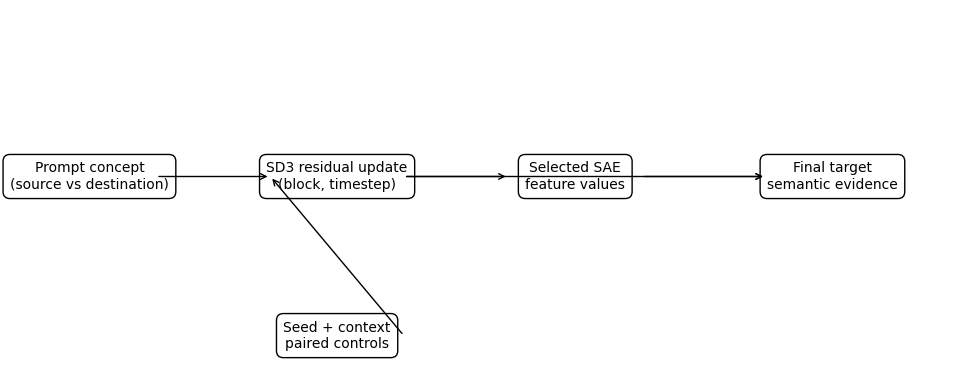

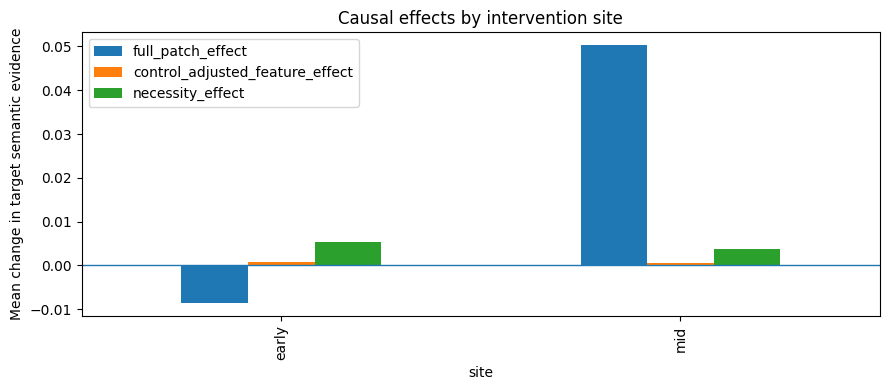

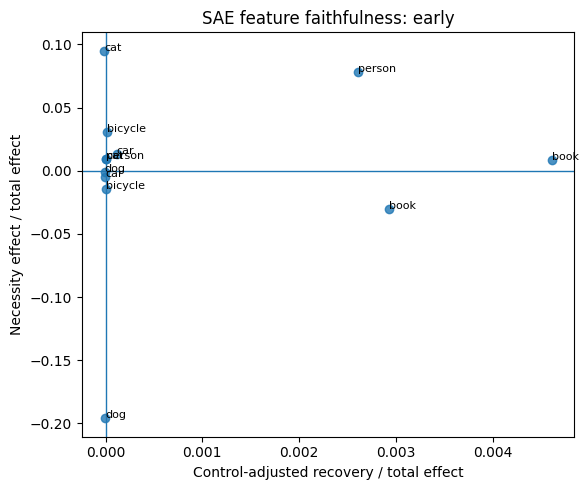

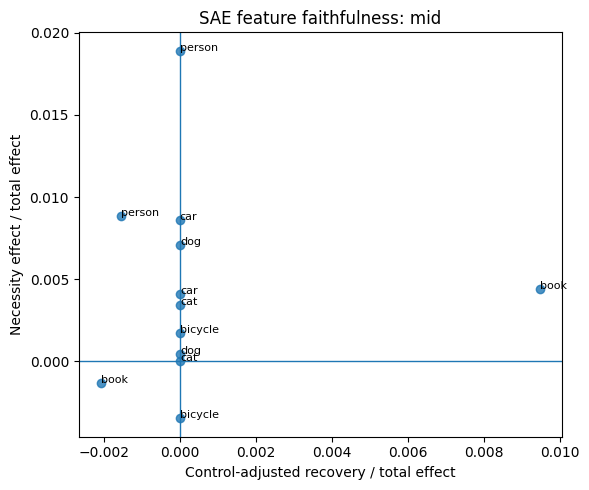

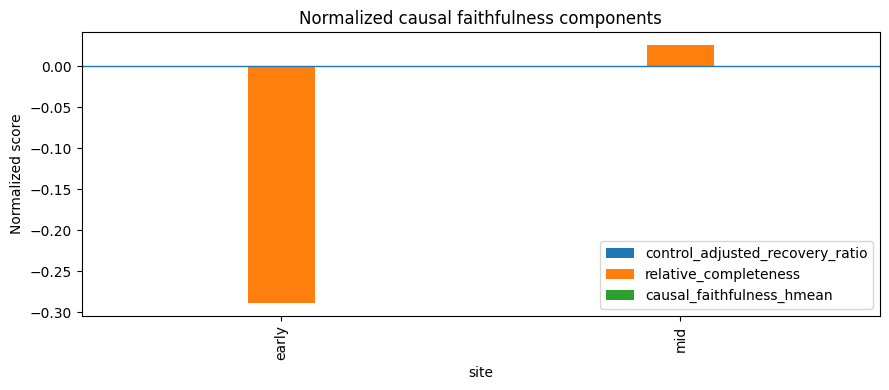

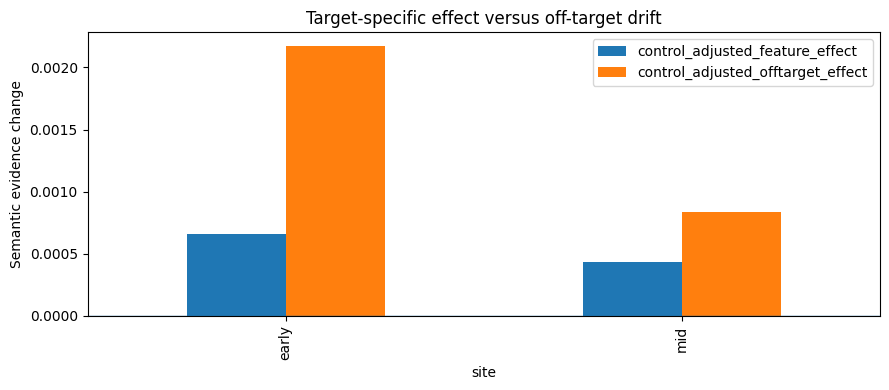

In [18]:
import matplotlib.pyplot as plt


def save_current(name):
    path = OUT_DIR / "figures" / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path


# Causal graph.
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
nodes = {
    "Prompt concept\n(source vs destination)": (0.08, 0.55),
    "SD3 residual update\n(block, timestep)": (0.34, 0.55),
    "Selected SAE\nfeature values": (0.59, 0.55),
    "Final target\nsemantic evidence": (0.86, 0.55),
    "Seed + context\npaired controls": (0.34, 0.12),
}
for text, (x, y) in nodes.items():
    ax.text(x, y, text, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))
for a, b in [
    ("Prompt concept\n(source vs destination)", "SD3 residual update\n(block, timestep)"),
    ("SD3 residual update\n(block, timestep)", "Selected SAE\nfeature values"),
    ("Selected SAE\nfeature values", "Final target\nsemantic evidence"),
    ("SD3 residual update\n(block, timestep)", "Final target\nsemantic evidence"),
    ("Seed + context\npaired controls", "SD3 residual update\n(block, timestep)"),
]:
    x1, y1 = nodes[a]; x2, y2 = nodes[b]
    ax.annotate("", xy=(x2 - 0.07, y2), xytext=(x1 + 0.07, y1), arrowprops=dict(arrowstyle="->"))
save_current("causal_design.png")

if not estimands.empty:
    plot_metrics = ["full_patch_effect", "control_adjusted_feature_effect", "necessity_effect"]
    summary_plot = estimands.groupby("site")[plot_metrics].mean()
    summary_plot.plot(kind="bar", figsize=(9, 4))
    plt.axhline(0, linewidth=1)
    plt.ylabel("Mean change in target semantic evidence")
    plt.title("Causal effects by intervention site")
    save_current("causal_effects_by_site.png")

    valid = estimands[estimands["valid_total_effect"]].copy()
    if not valid.empty:
        for site, sub in valid.groupby("site"):
            plt.figure(figsize=(6, 5))
            plt.scatter(sub["control_adjusted_recovery_ratio"], sub["necessity_ratio"], alpha=0.8)
            for _, r in sub.iterrows():
                plt.annotate(str(r["label"]), (r["control_adjusted_recovery_ratio"], r["necessity_ratio"]), fontsize=8)
            plt.axhline(0, linewidth=1)
            plt.axvline(0, linewidth=1)
            plt.xlabel("Control-adjusted recovery / total effect")
            plt.ylabel("Necessity effect / total effect")
            plt.title(f"SAE feature faithfulness: {site}")
            save_current(f"necessity_vs_recovery_{site}.png")

        valid.groupby("site")[["control_adjusted_recovery_ratio", "relative_completeness", "causal_faithfulness_hmean"]].mean().plot(kind="bar", figsize=(9, 4))
        plt.axhline(0, linewidth=1)
        plt.ylabel("Normalized score")
        plt.title("Normalized causal faithfulness components")
        save_current("normalized_faithfulness_by_site.png")

    estimands.groupby("site")[["control_adjusted_feature_effect", "control_adjusted_offtarget_effect"]].mean().plot(kind="bar", figsize=(9, 4))
    plt.axhline(0, linewidth=1)
    plt.ylabel("Semantic evidence change")
    plt.title("Target-specific effect versus off-target drift")
    save_current("target_vs_offtarget.png")

## 15. Counterfactual galleries

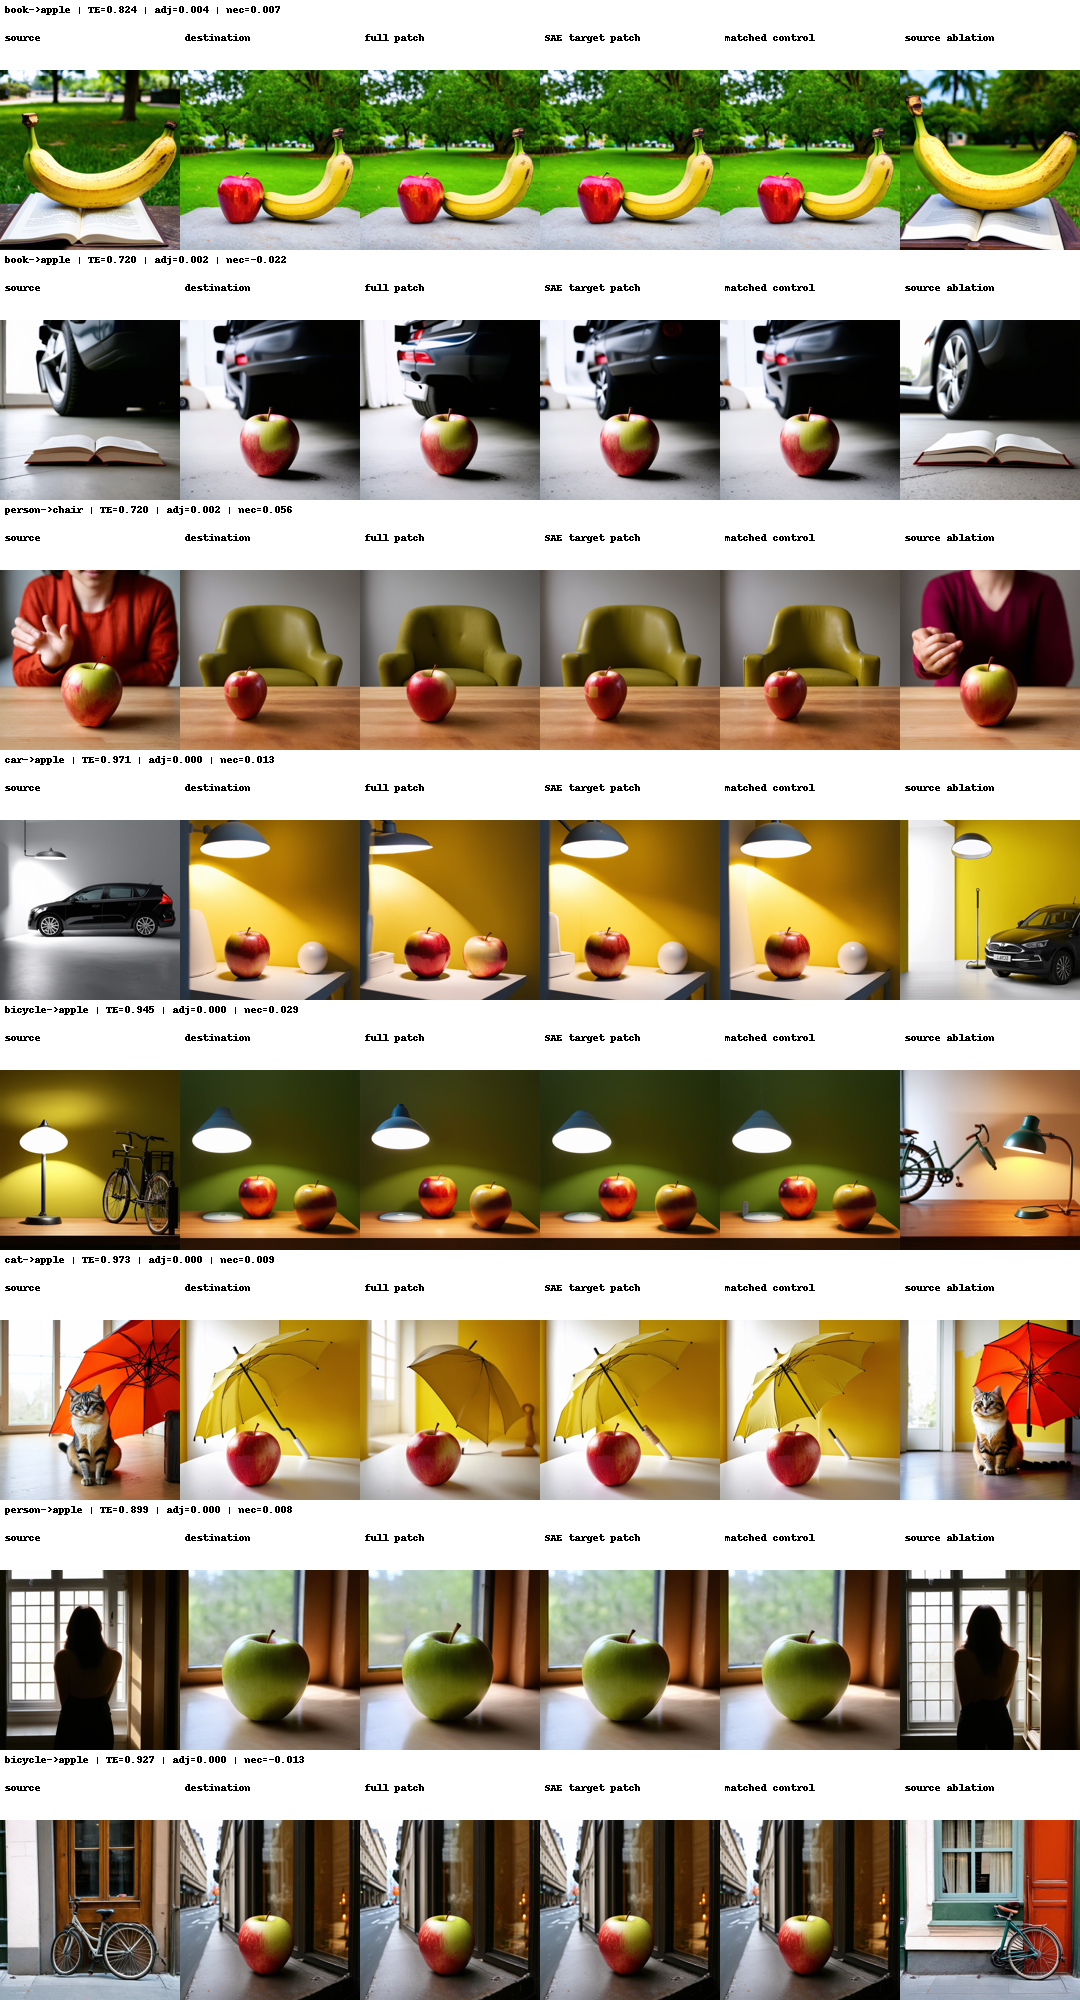

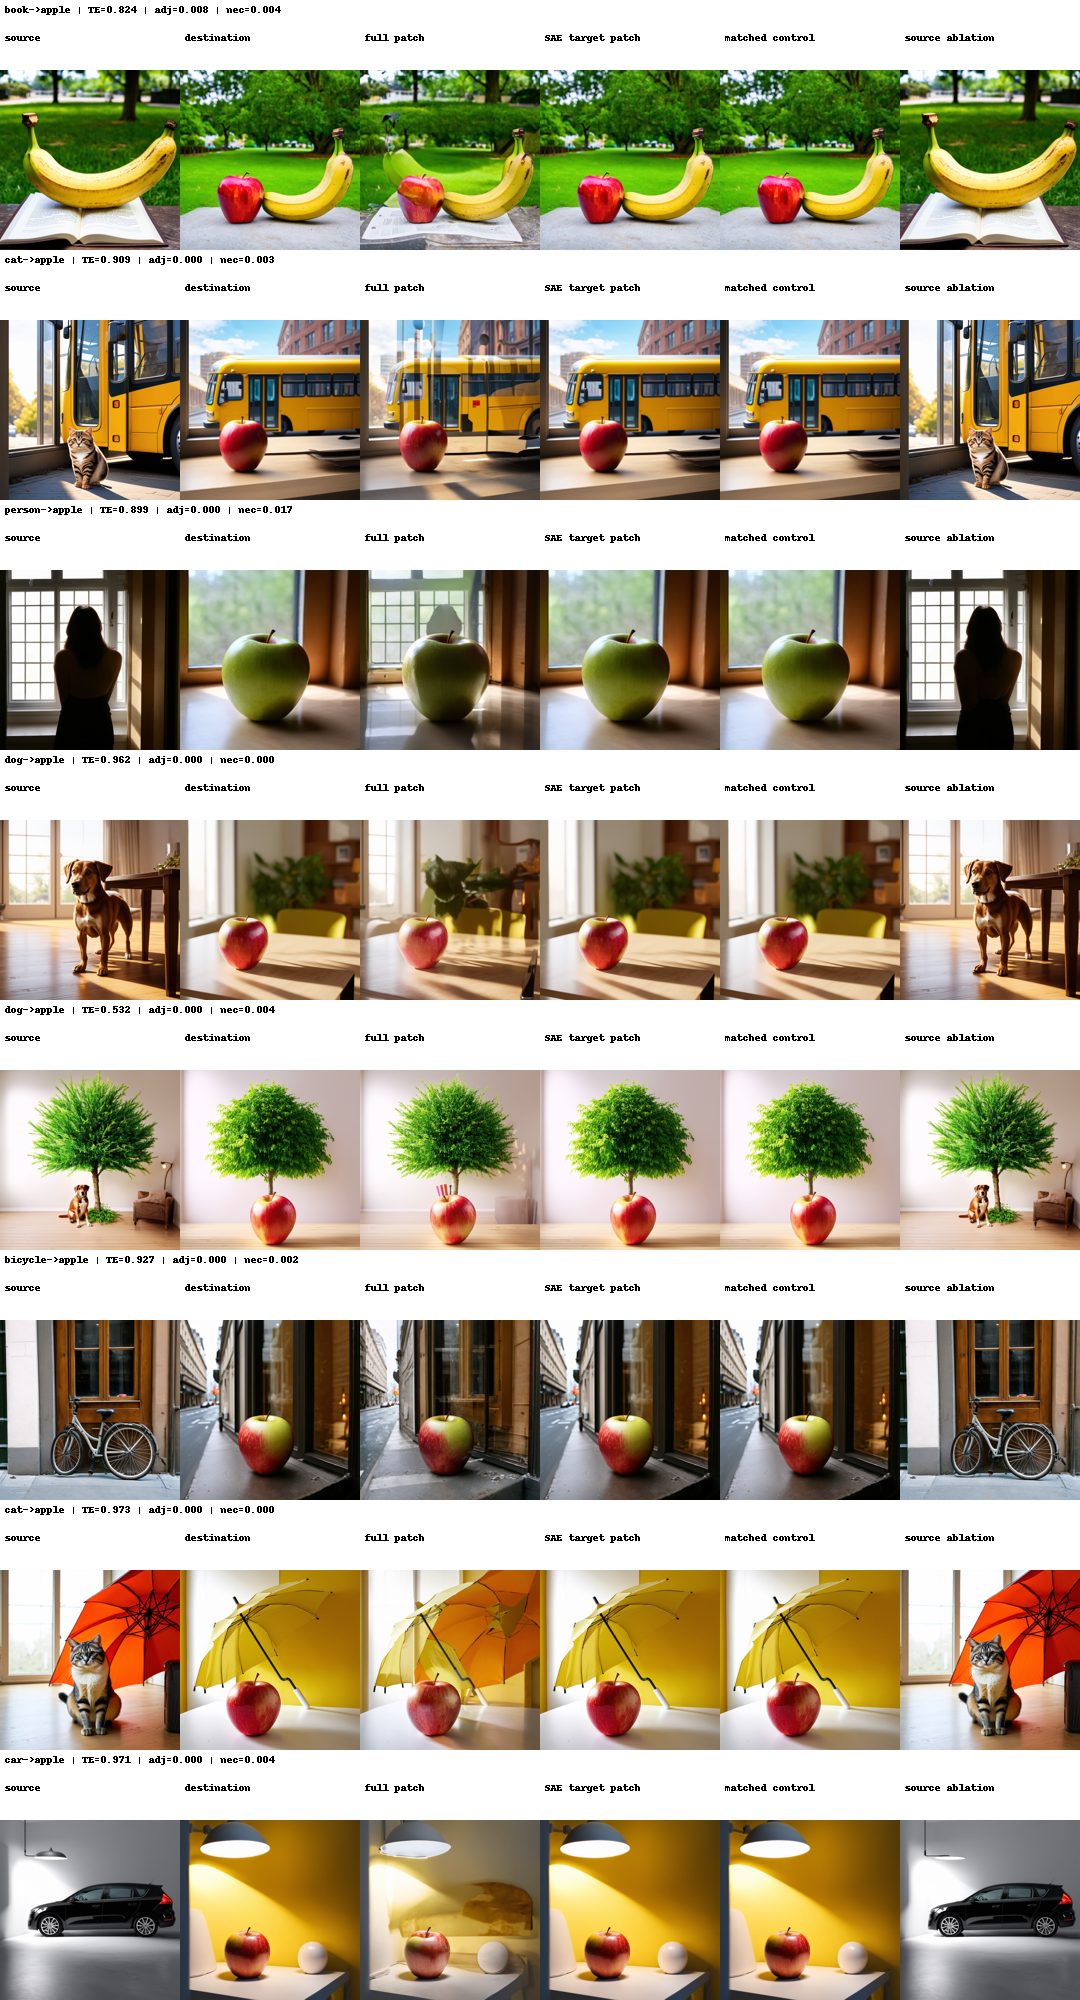

In [20]:
from PIL import ImageDraw


def _thumb(path, size=(180, 180)):
    image = Image.open(path).convert("RGB")
    image.thumbnail(size)
    canvas = Image.new("RGB", size, "white")
    canvas.paste(image, ((size[0] - image.width) // 2, (size[1] - image.height) // 2))
    return canvas


def make_causal_gallery(df, site, max_rows=8, save_path=None):
    sub = df[df["site"].eq(site)].head(max_rows)
    if sub.empty:
        return None
    cols = [
        ("source", "source_path"),
        ("destination", "destination_path"),
        ("full patch", "full_patch_path"),
        ("SAE target patch", "target_patch_path"),
        ("matched control", "control_patch_path"),
        ("source ablation", "ablation_path"),
    ]
    w, h = 180, 180
    title_h = 70
    canvas = Image.new("RGB", (len(cols) * w, len(sub) * (h + title_h)), "white")
    draw = ImageDraw.Draw(canvas)
    for ri, (_, row) in enumerate(sub.iterrows()):
        y = ri * (h + title_h)
        title = (
            f"{row['label']}->{row['replacement_label']} | TE={row['total_effect']:.3f} | "
            f"adj={row['control_adjusted_feature_effect']:.3f} | nec={row['necessity_effect']:.3f}"
        )
        draw.text((5, y + 4), title[:180], fill=(0, 0, 0))
        for ci, (name, col) in enumerate(cols):
            x = ci * w
            draw.text((x + 5, y + 32), name, fill=(0, 0, 0))
            canvas.paste(_thumb(row[col], (w, h)), (x, y + title_h))
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        canvas.save(save_path)
    return canvas


if not estimands.empty:
    for site in RUN_SITES:
        gallery = make_causal_gallery(
            estimands.sort_values("control_adjusted_feature_effect", ascending=False),
            site,
            max_rows=8,
            save_path=OUT_DIR / "galleries" / f"causal_gallery_{site}.png",
        )
        if gallery is not None:
            display(gallery)

## 16. Final artifact inventory and checks

In [21]:
expected = [
    OUT_DIR / "prompt_pairs.jsonl",
    OUT_DIR / "feature_selection.csv",
    OUT_DIR / "run_manifest.csv",
    OUT_DIR / "semantic_scores.csv",
    OUT_DIR / "causal_estimands.csv",
    OUT_DIR / "causal_summary.csv",
]
expected.extend(sorted((OUT_DIR / "figures").glob("*.png")))
expected.extend(sorted((OUT_DIR / "galleries").glob("*.png")))

inventory = pd.DataFrame([
    {
        "path": str(path),
        "exists": path.exists(),
        "size_mib": path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
    }
    for path in expected
])
display(inventory)

checks = []
if not estimands.empty:
    for site, sub in estimands.groupby("site"):
        valid = sub[sub["valid_total_effect"]]
        checks.append({
            "site": site,
            "pairs": len(sub),
            "valid_total_effect_pairs": len(valid),
            "mean_control_adjusted_effect": sub["control_adjusted_feature_effect"].mean(),
            "mean_necessity_effect": sub["necessity_effect"].mean(),
            "mean_relative_completeness": valid["relative_completeness"].mean(),
            "interchange_improved_rate": sub["interchange_improved"].mean(),
            "mean_target_patch_ssim": sub["target_patch_ssim"].mean(),
        })
if checks:
    display(pd.DataFrame(checks))

print("Output directory:", OUT_DIR)

,path,exists,size_mib
0,/home/jupyter/project/diffusion_attention_anal...,True,0.007133
1,/home/jupyter/project/diffusion_attention_anal...,True,0.004051
2,/home/jupyter/project/diffusion_attention_anal...,True,0.096928
3,/home/jupyter/project/diffusion_attention_anal...,True,0.155659
4,/home/jupyter/project/diffusion_attention_anal...,True,0.038227
5,/home/jupyter/project/diffusion_attention_anal...,True,0.002077
6,/home/jupyter/project/diffusion_attention_anal...,True,0.052291
7,/home/jupyter/project/diffusion_attention_anal...,True,0.056163
8,/home/jupyter/project/diffusion_attention_anal...,True,0.062103
9,/home/jupyter/project/diffusion_attention_anal...,True,0.063490


,site,pairs,valid_total_effect_pairs,mean_control_adjusted_effect,mean_necessity_effect,mean_relative_completeness,interchange_improved_rate,mean_target_patch_ssim
0,early,12,12,0.000658,0.005277,-0.288809,0.333333,0.967134
1,mid,12,12,0.000434,0.003649,0.025777,0.500000,0.998616


Output directory: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/06_causal_faithfulness
